# 🌊 Chennai Reservoir Water Level Prediction
### Complete Machine Learning Project
**Dataset:** Chennai Reservoir Levels & Rainfall (2004 – 2020)  
**Goal:** Predict total water level in Chennai reservoirs using rainfall and historical level data  
**Author:** *(Your Name)*

---

## 📦 BATCH 1 – Mount Google Drive & Install Libraries

In [ ]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# ── Install any extra libraries if needed ───────────────────────────────────
!pip install scikit-learn xgboost matplotlib seaborn pandas numpy --quiet
print("✅ All libraries ready!")

✅ All libraries ready!


---
## 📚 BATCH 2 – Import All Libraries

In [ ]:
# ── Core ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ── Metrics ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

# ── Time series helper ───────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

print("✅ All imports successful!")

✅ All imports successful!


---
## 📂 BATCH 3 – Load Dataset

> **How to upload:**  
> 1. Open the **Files** panel on the left sidebar in Colab  
> 2. Upload `chennai_reservoir_levels.csv` and `chennai_reservoir_rainfall.csv`  
> 3. Or place them inside your Google Drive and adjust the path below

In [ ]:
# ── Option A: Uploaded directly to Colab session (most common) ──────────────
#LEVELS_PATH   = '/content/chennai_reservoir_levels.csv'
#RAINFALL_PATH = '/content/chennai_reservoir_rainfall.csv'

# ── Option B: From Google Drive (uncomment & edit path if needed) ─────────
LEVELS_PATH   = '/content/drive/MyDrive/DatasetC/chennai_reservoir_levels.csv'
RAINFALL_PATH = '/content/drive/MyDrive/DatasetC/chennai_reservoir_rainfall.csv'

levels_df   = pd.read_csv(LEVELS_PATH)
rainfall_df = pd.read_csv(RAINFALL_PATH)

print(f"✅ Levels   dataset loaded  → {levels_df.shape[0]:,} rows × {levels_df.shape[1]} cols")
print(f"✅ Rainfall dataset loaded  → {rainfall_df.shape[0]:,} rows × {rainfall_df.shape[1]} cols")

✅ Levels   dataset loaded  → 6,182 rows × 5 cols
✅ Rainfall dataset loaded  → 6,182 rows × 5 cols


---
## 🔍 BATCH 4 – Exploratory Data Analysis (EDA)

In [ ]:
# ── Quick peek ───────────────────────────────────────────────────────────────
print("=" * 55)
print("  LEVELS DATASET – First 5 rows")
print("=" * 55)
display(levels_df.head())

print("\n" + "=" * 55)
print("  RAINFALL DATASET – First 5 rows")
print("=" * 55)
display(rainfall_df.head())

  LEVELS DATASET – First 5 rows


,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0



  RAINFALL DATASET – First 5 rows


,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,0.0,0.0,0.0,0.0
1,02-01-2004,0.0,0.0,0.0,0.0
2,03-01-2004,0.0,0.0,0.0,0.0
3,04-01-2004,0.0,0.0,0.0,0.0
4,05-01-2004,0.0,0.0,0.0,0.0


In [ ]:
# ── Shape, dtypes & missing values ──────────────────────────────────────────
for name, df in [("LEVELS", levels_df), ("RAINFALL", rainfall_df)]:
    print(f"\n{'='*55}")
    print(f"  {name} DATASET INFO")
    print(f"{'='*55}")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum())


  LEVELS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6182 entries, 0 to 6181
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             6182 non-null   object 
 1   POONDI           6182 non-null   float64
 2   CHOLAVARAM       6182 non-null   float64
 3   REDHILLS         6182 non-null   float64
 4   CHEMBARAMBAKKAM  6182 non-null   float64
dtypes: float64(4), object(1)
memory usage: 241.6+ KB
None

Missing values:
Date               0
POONDI             0
CHOLAVARAM         0
REDHILLS           0
CHEMBARAMBAKKAM    0
dtype: int64

  RAINFALL DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6182 entries, 0 to 6181
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             6182 non-null   object 
 1   POONDI           6182 non-null   float64
 2   CHOLAVARAM       6182 non-null   fl

In [ ]:
# ── Statistical summary ──────────────────────────────────────────────────────
print("LEVELS – Descriptive Statistics")
display(levels_df.describe().round(2))

print("\nRAINFALL – Descriptive Statistics")
display(rainfall_df.describe().round(2))

LEVELS – Descriptive Statistics


,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
count,6182.00,6182.00,6182.00,6182.00
mean,1106.74,226.40,1592.32,1321.46
std,1004.56,266.89,915.24,951.79
min,0.90,0.00,0.00,0.00
25%,202.00,26.00,847.25,459.25
50%,783.15,89.00,1685.00,1264.00
75%,1918.00,411.00,2320.00,2046.75
max,3231.00,896.00,3300.00,3396.00



RAINFALL – Descriptive Statistics


,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
count,6182.00,6182.00,6182.00,6182.00
mean,3.46,3.73,3.83,3.97
std,12.99,14.19,14.98,16.09
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00
max,300.00,293.00,320.00,475.00


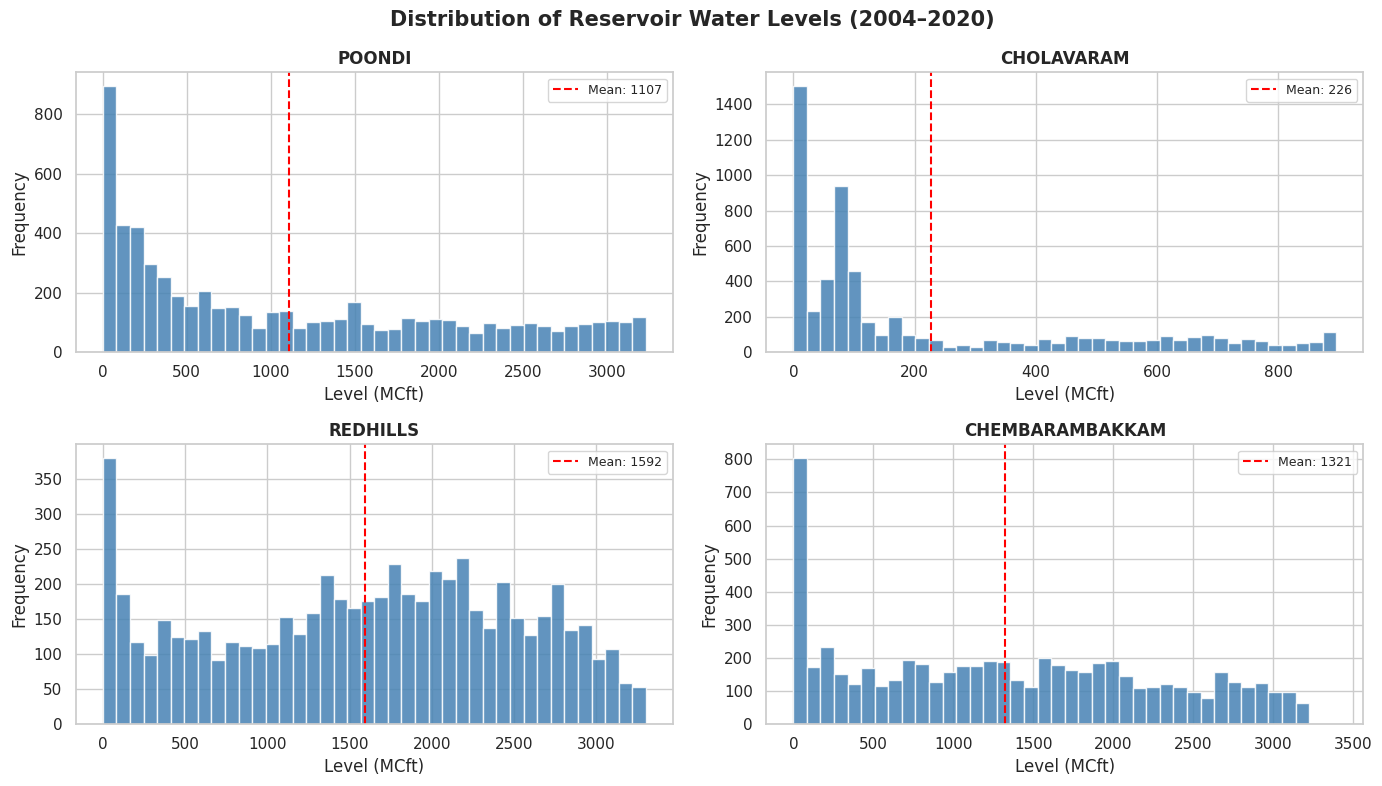

In [ ]:
# ── Distribution of reservoir levels ────────────────────────────────────────
reservoirs = ['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distribution of Reservoir Water Levels (2004–2020)",
             fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), reservoirs):
    ax.hist(levels_df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel("Level (MCft)")
    ax.set_ylabel("Frequency")
    mean_val = levels_df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f"Mean: {mean_val:.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

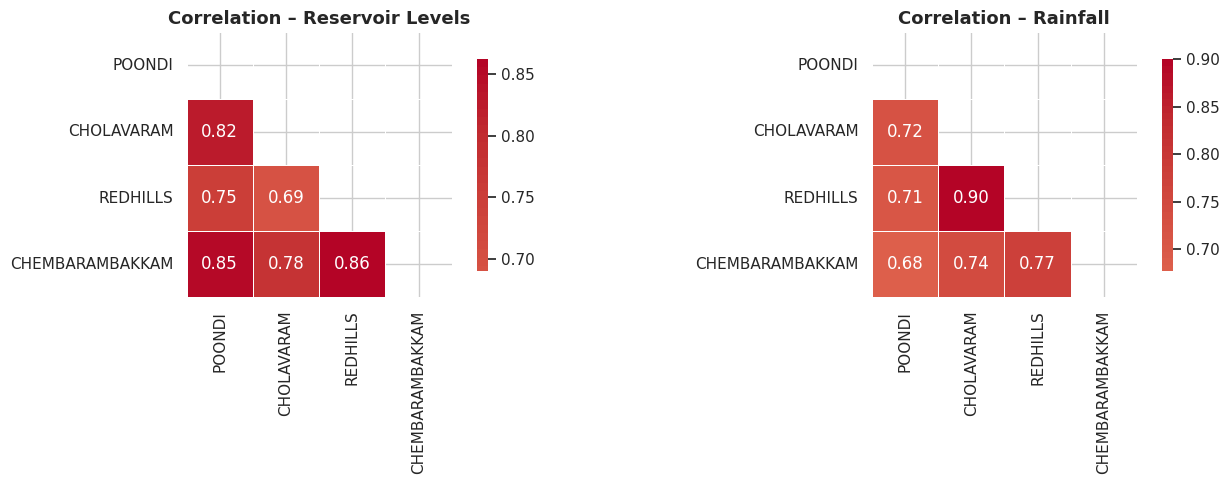

In [ ]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [(axes[0], levels_df[reservoirs],   "Reservoir Levels"),
                      (axes[1], rainfall_df[reservoirs],  "Rainfall")]:
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                center=0, square=True, linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlation – {title}", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🛠️ BATCH 5 – Data Preprocessing & Feature Engineering

In [ ]:
# ── Parse dates & merge datasets ─────────────────────────────────────────────
levels_df['Date']   = pd.to_datetime(levels_df['Date'],   dayfirst=True)
rainfall_df['Date'] = pd.to_datetime(rainfall_df['Date'], dayfirst=True)

df = pd.merge(levels_df, rainfall_df, on='Date', suffixes=('_level', '_rain'))
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Merged shape: {df.shape}")
display(df.head())

✅ Merged shape: (6182, 9)


,Date,POONDI_level,CHOLAVARAM_level,REDHILLS_level,CHEMBARAMBAKKAM_level,POONDI_rain,CHOLAVARAM_rain,REDHILLS_rain,CHEMBARAMBAKKAM_rain
0,2004-01-01,3.9,0.0,268.0,0.0,0.0,0.0,0.0,0.0
1,2004-01-02,3.9,0.0,268.0,0.0,0.0,0.0,0.0,0.0
2,2004-01-03,3.9,0.0,267.0,0.0,0.0,0.0,0.0,0.0
3,2004-01-04,3.9,0.0,267.0,0.0,0.0,0.0,0.0,0.0
4,2004-01-05,3.8,0.0,267.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ── Create TARGET variable: total water level across all 4 reservoirs ────────
level_cols = ['POONDI_level', 'CHOLAVARAM_level', 'REDHILLS_level', 'CHEMBARAMBAKKAM_level']
rain_cols  = ['POONDI_rain',  'CHOLAVARAM_rain',  'REDHILLS_rain',  'CHEMBARAMBAKKAM_rain']

df['TOTAL_LEVEL']    = df[level_cols].sum(axis=1)
df['TOTAL_RAINFALL'] = df[rain_cols].sum(axis=1)

# ── Date-based features ───────────────────────────────────────────────────────
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Day']     = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Quarter'] = df['Date'].dt.quarter

# ── Seasonal encoding (cyclical) ─────────────────────────────────────────────
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Day_sin']   = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['Day_cos']   = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# ── Lag features: previous 7 & 30 days total level ───────────────────────────
df['Lag_7_level']  = df['TOTAL_LEVEL'].shift(7)
df['Lag_30_level'] = df['TOTAL_LEVEL'].shift(30)

# ── Rolling statistics ────────────────────────────────────────────────────────
df['Roll_7_rain_mean']  = df['TOTAL_RAINFALL'].rolling(7).mean()
df['Roll_30_rain_mean'] = df['TOTAL_RAINFALL'].rolling(30).mean()
df['Roll_7_level_std']  = df['TOTAL_LEVEL'].rolling(7).std()

# ── Drop rows with NaN created by lag/rolling ─────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Feature engineering complete  →  {df.shape[0]:,} rows × {df.shape[1]} cols")
print("\nNew feature columns:", [c for c in df.columns if c not in ['Date'] + level_cols + rain_cols])

✅ Feature engineering complete  →  6,152 rows × 25 cols

New feature columns: ['TOTAL_LEVEL', 'TOTAL_RAINFALL', 'Year', 'Month', 'Day', 'DayOfYear', 'Quarter', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Lag_7_level', 'Lag_30_level', 'Roll_7_rain_mean', 'Roll_30_rain_mean', 'Roll_7_level_std']


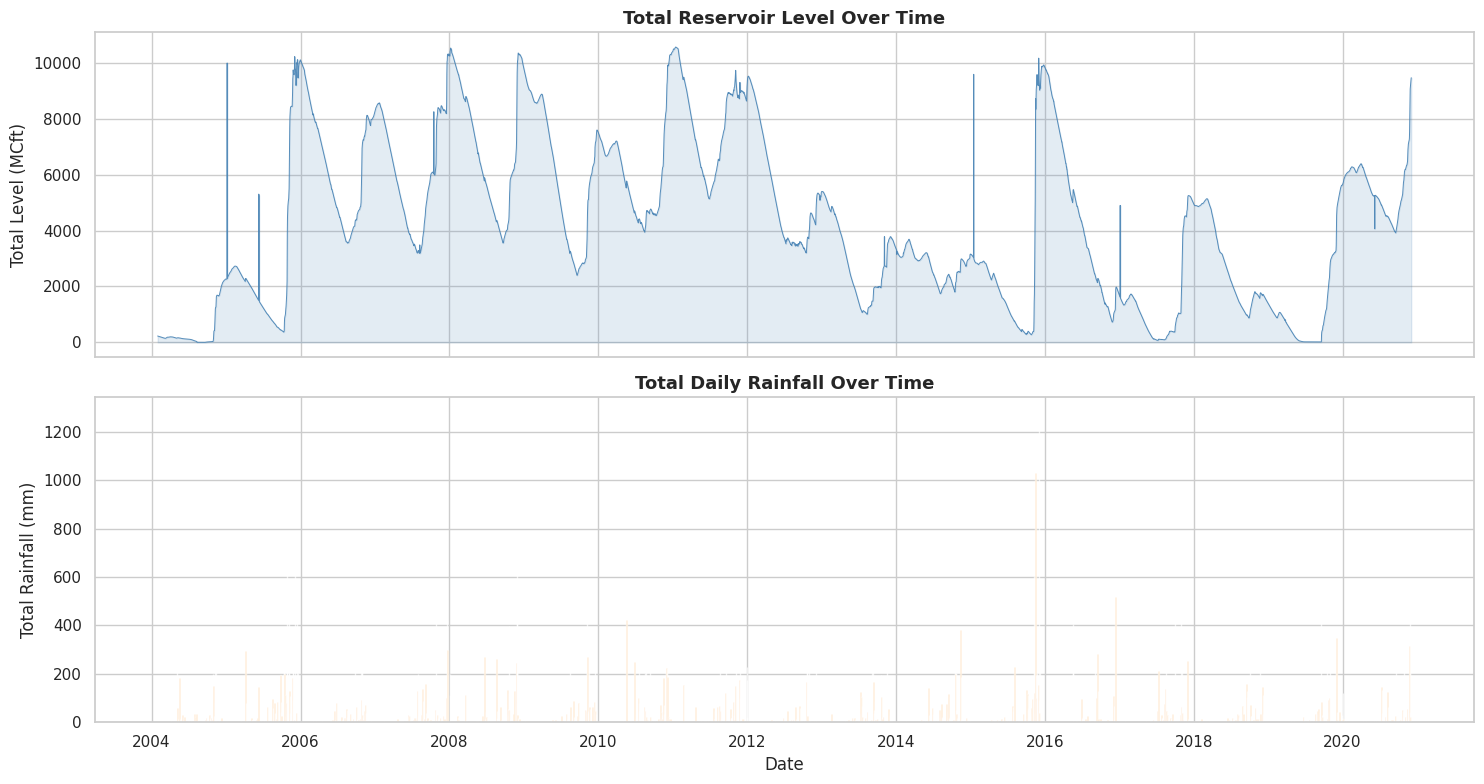

In [ ]:
# ── Total water level over time ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df['Date'], df['TOTAL_LEVEL'], color='steelblue', linewidth=0.7, alpha=0.9)
axes[0].set_title("Total Reservoir Level Over Time", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Total Level (MCft)")
axes[0].fill_between(df['Date'], df['TOTAL_LEVEL'], alpha=0.15, color='steelblue')

axes[1].bar(df['Date'], df['TOTAL_RAINFALL'], color='darkorange', width=1, alpha=0.7)
axes[1].set_title("Total Daily Rainfall Over Time", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Rainfall (mm)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

---
## ✂️ BATCH 6 – Train / Test Split & Scaling

In [ ]:
# Leakage-free forecasting setup

# Forecast 7 days ahead
df['TARGET_LEVEL_7D'] = df['TOTAL_LEVEL'].shift(-7)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = (
    rain_cols +
    [
        "Year", "Month", "Quarter", "DayOfYear",
        "Month_sin", "Month_cos", "Day_sin", "Day_cos",
        "TOTAL_RAINFALL",
        "Lag_7_level", "Lag_30_level",
        "Roll_7_rain_mean", "Roll_30_rain_mean",
        "Roll_7_level_std"
    ]
)

TARGET_COL = "TARGET_LEVEL_7D"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET_COL}")

Features: 18
Target: TARGET_LEVEL_7D


In [ ]:
# ── Chronological train/test split (no shuffle – time series) ────────────────
SPLIT_RATIO = 0.80
split_idx   = int(len(X) * SPLIT_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set   : {X_train.shape[0]:,} samples  ({SPLIT_RATIO*100:.0f}%)")
print(f"Testing  set   : {X_test.shape[0]:,} samples  ({(1-SPLIT_RATIO)*100:.0f}%)")
print(f"Train period   : {df['Date'].iloc[0].date()} → {df['Date'].iloc[split_idx-1].date()}")
print(f"Test  period   : {df['Date'].iloc[split_idx].date()} → {df['Date'].iloc[-1].date()}")

Training set   : 4,916 samples  (80%)
Testing  set   : 1,229 samples  (20%)
Train period   : 2004-01-31 → 2017-07-16
Test  period   : 2017-07-17 → 2020-11-26


In [ ]:
# ── Standard Scaling ─────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling complete  (mean≈0, std≈1 on training set)")

✅ Scaling complete  (mean≈0, std≈1 on training set)


---
## 🤖 BATCH 7 – Train & Compare Multiple Models

In [ ]:
import numpy as np
# ── Helper: evaluate one model ────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    return {"Model": name, "MAE": round(mae, 2),
            "RMSE": round(rmse, 2), "R2": round(r2, 4),
            "Predictions": pred, "Object": model}

# ── Define models ─────────────────────────────────────────────────────────────
MODELS = {
    "Linear Regression"     : LinearRegression(),
    "Ridge Regression"      : Ridge(alpha=1.0),
    "Lasso Regression"      : Lasso(alpha=0.5),
    "Decision Tree"         : DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest"         : RandomForestRegressor(n_estimators=200, max_depth=15,
                                                     random_state=42, n_jobs=-1),
    "Extra Trees"           : ExtraTreesRegressor(n_estimators=200, random_state=42,
                                                   n_jobs=-1),
    "Gradient Boosting"     : GradientBoostingRegressor(n_estimators=200,
                                                         learning_rate=0.05,
                                                         max_depth=5,
                                                         random_state=42),
    "XGBoost"               : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                            max_depth=6, subsample=0.8,
                                            colsample_bytree=0.8,
                                            random_state=42, verbosity=0),
}

# ── Train all models ──────────────────────────────────────────────────────────
results      = []
predictions  = {}

print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("—" * 57)

for name, model in MODELS.items():
    res = evaluate_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    results.append({k: v for k, v in res.items() if k != "Predictions" and k != "Object"})
    predictions[name]  = res["Predictions"]
    MODELS[name]       = res["Object"]        # save fitted model
    print(f"{res['Model']:<25} {res['MAE']:>10.2f} {res['RMSE']:>10.2f} {res['R2']:>8.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\n✅ All models trained!")

Model                            MAE       RMSE       R²
—————————————————————————————————————————————————————————
Linear Regression             281.98     378.40   0.9718
Ridge Regression              283.00     379.40   0.9717
Lasso Regression              282.25     378.91   0.9717
Decision Tree                 419.51     874.94   0.8493
Random Forest                 249.02     399.85   0.9685
Extra Trees                   261.90     399.26   0.9686
Gradient Boosting             296.78     474.39   0.9557
XGBoost                       335.41     496.52   0.9515

✅ All models trained!


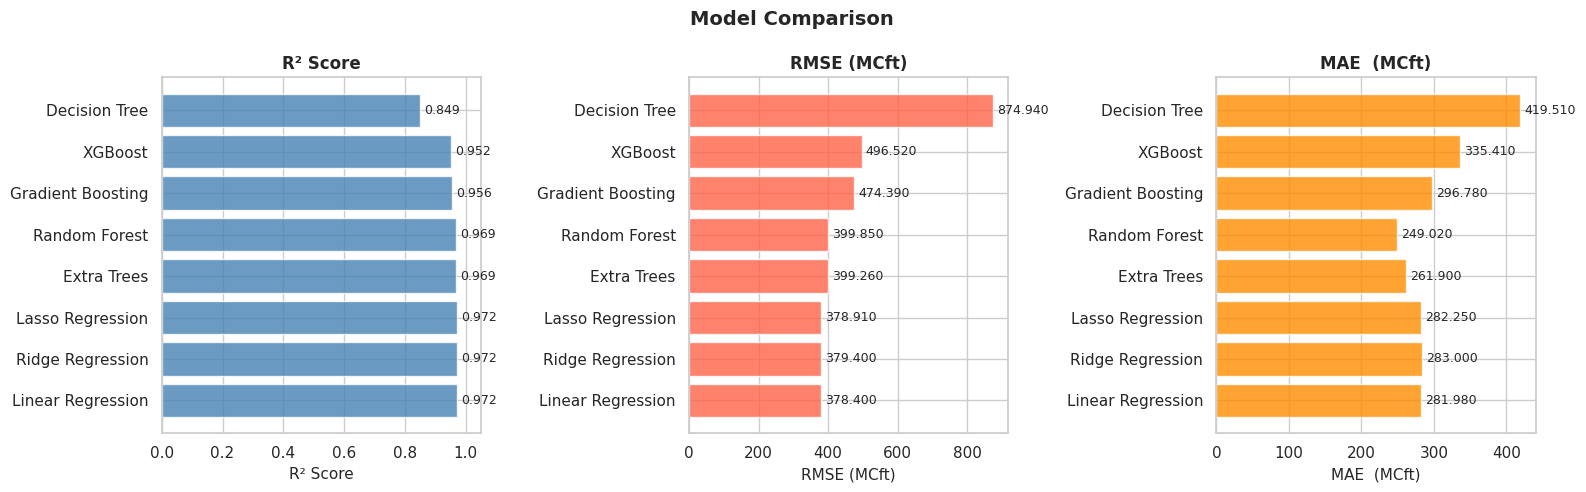


📊 Results Table (sorted by R²):


,Model,MAE,RMSE,R2
0,Linear Regression,281.98,378.40,0.9718
1,Ridge Regression,283.00,379.40,0.9717
2,Lasso Regression,282.25,378.91,0.9717
5,Extra Trees,261.90,399.26,0.9686
4,Random Forest,249.02,399.85,0.9685
6,Gradient Boosting,296.78,474.39,0.9557
7,XGBoost,335.41,496.52,0.9515
3,Decision Tree,419.51,874.94,0.8493


In [ ]:
# ── Results bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight='bold')

metrics   = [("R2",   "R² Score",   'steelblue'),
             ("RMSE", "RMSE (MCft)", 'tomato'),
             ("MAE",  "MAE  (MCft)", 'darkorange')]

for ax, (col, label, color) in zip(axes, metrics):
    vals  = results_df[col]
    bars  = ax.barh(results_df["Model"], vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    if col == "R2":
        ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

print("\n📊 Results Table (sorted by R²):")
display(results_df)

---
## 🏆 BATCH 8 – Best Model Deep Dive

In [ ]:
HORIZON = 7   # forecast 7 days ahead
LAG     = 12  # use level from 12 days ago (NOT 7 — avoids
              # near-duplicate of the 7-day-ahead target)

df['Lag_level']         = df['TOTAL_LEVEL'].shift(LAG)
df['Roll_7_rain_mean']  = df['TOTAL_RAINFALL'].rolling(7).mean()
df['Roll_30_rain_mean'] = df['TOTAL_RAINFALL'].rolling(30).mean()
df['Roll_level_std']    = df['TOTAL_LEVEL'].shift(LAG).rolling(7).std()

df['TARGET_LEVEL_7D'] = df['TOTAL_LEVEL'].shift(-HORIZON)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = (
    rain_cols +
    [
        "Year", "Month", "Quarter", "DayOfYear",
        "Month_sin", "Month_cos", "Day_sin", "Day_cos",
        "TOTAL_RAINFALL",
        "Lag_level",
        "Roll_7_rain_mean", "Roll_30_rain_mean",
        "Roll_level_std"
    ]
)

TARGET_COL = "TARGET_LEVEL_7D"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target: {TARGET_COL}")

Features: 17
Target: TARGET_LEVEL_7D


In [ ]:
# ── Cell 20 replacement: Chronological train/test split ────
SPLIT_RATIO = 0.80
split_idx   = int(len(X) * SPLIT_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set   : {X_train.shape[0]:,} samples  ({SPLIT_RATIO*100:.0f}%)")
print(f"Testing  set   : {X_test.shape[0]:,} samples  ({(1-SPLIT_RATIO)*100:.0f}%)")
print(f"Train period   : {df['Date'].iloc[0].date()} → {df['Date'].iloc[split_idx-1].date()}")
print(f"Test  period   : {df['Date'].iloc[split_idx].date()} → {df['Date'].iloc[-1].date()}")

Training set   : 4,887 samples  (80%)
Testing  set   : 1,222 samples  (20%)
Train period   : 2004-02-29 → 2017-07-16
Test  period   : 2017-07-17 → 2020-11-19


In [ ]:
best_name  = results_df.iloc[0]["Model"]
best_model = MODELS[best_name]
# Re-predict using the best model and the current scaled test features
best_pred  = best_model.predict(X_test_sc)

print(f"🥇  Best Model  : {best_name}")
print(f"    R²          : {results_df.iloc[0]['R2']:.4f}")
print(f"    RMSE        : {results_df.iloc[0]['RMSE']:.2f} MCft")
print(f"    MAE         : {results_df.iloc[0]['MAE']:.2f} MCft")

🥇  Best Model  : Lasso Regression
    R²          : 0.9569
    RMSE        : 458.81 MCft
    MAE         : 354.39 MCft


In [ ]:
# ── Cell 21 replacement: Standard Scaling ───────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling complete  (mean≈0, std≈1 on training set)")


✅ Scaling complete  (mean≈0, std≈1 on training set)


After redefining the features for the 'Best Model Deep Dive' in Cell `wVvF6g-sMUKr`, the `X_train_sc` and `X_test_sc` now have 17 features instead of 18. The previously trained models in `MODELS` were trained on 18 features. To resolve the `ValueError` during prediction, we need to re-train all models with the new 17-feature dataset.

In [ ]:
# ── Re-train all models with the updated feature set ────────────────────────
# The `evaluate_model` function and `MODELS` dictionary are already defined in cell `2ac31f23`
# We need to re-run the training loop to update the models with the new X_train_sc and y_train

results      = []
predictions  = {}

print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("—" * 57)

for name, model in MODELS.items():
    res = evaluate_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    results.append({k: v for k, v in res.items() if k != "Predictions" and k != "Object"})
    predictions[name]  = res["Predictions"]
    MODELS[name]       = res["Object"]        # save fitted model
    print(f"{res['Model']:<25} {res['MAE']:>10.2f} {res['RMSE']:>10.2f} {res['R2']:>8.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\n✅ All models re-trained with updated features!")

Model                            MAE       RMSE       R²
—————————————————————————————————————————————————————————
Linear Regression             354.47     459.23   0.9568
Ridge Regression              354.55     459.32   0.9568
Lasso Regression              354.39     458.81   0.9569
Decision Tree                 454.17     807.40   0.8666
Random Forest                 335.86     546.47   0.9389
Extra Trees                   372.14     536.36   0.9411
Gradient Boosting             402.69     587.41   0.9294
XGBoost                       732.18     965.86   0.8091

✅ All models re-trained with updated features!


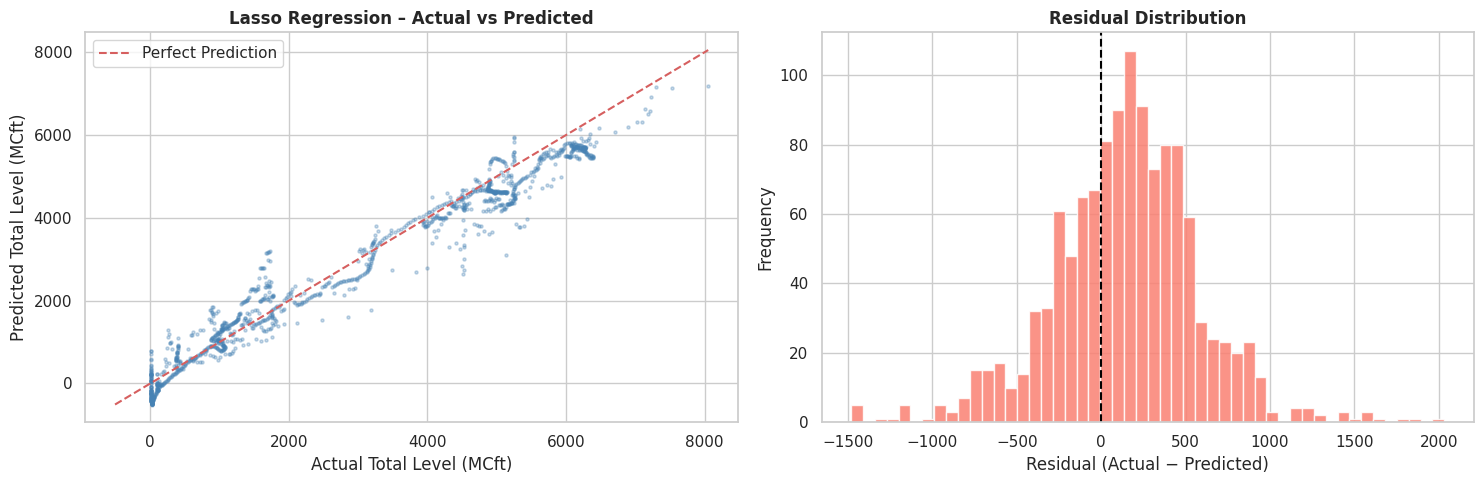

In [ ]:
# ── Actual vs Predicted scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter
axes[0].scatter(y_test, best_pred, alpha=0.3, s=5, color='steelblue')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel("Actual Total Level (MCft)")
axes[0].set_ylabel("Predicted Total Level (MCft)")
axes[0].set_title(f"{best_name} – Actual vs Predicted", fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - best_pred
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

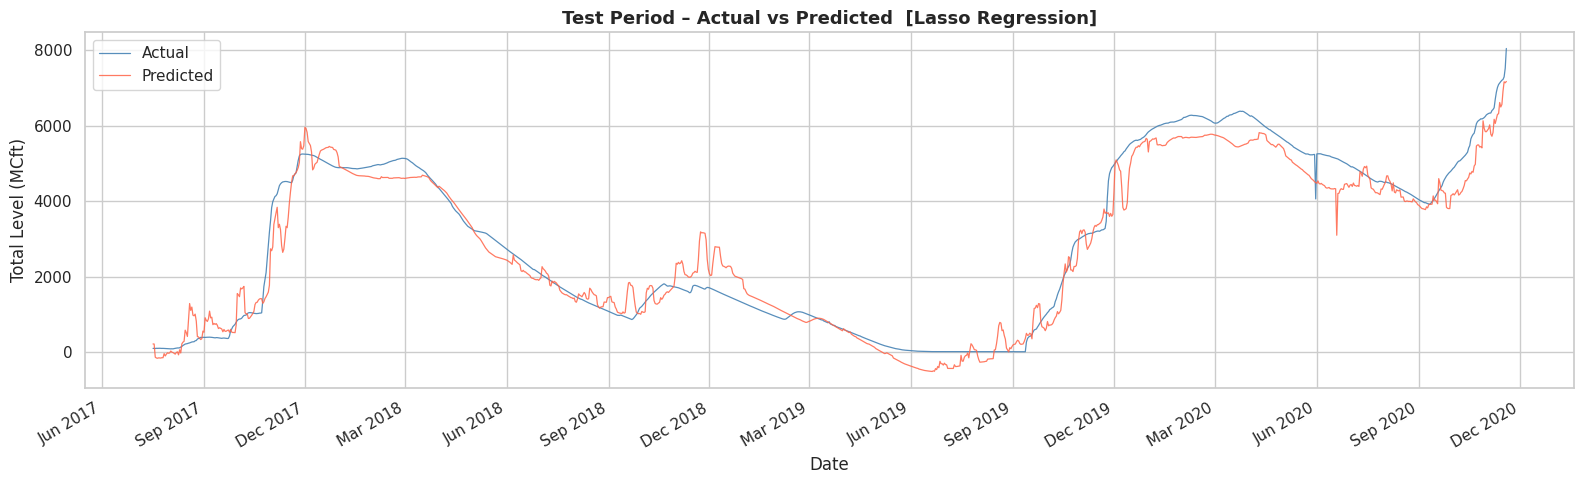

In [ ]:
# ── Time-series: Actual vs Predicted over test period ────────────────────────
test_dates = df['Date'].iloc[split_idx:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates, y_test,    color='steelblue',  linewidth=0.9, label='Actual',    alpha=0.9)
ax.plot(test_dates, best_pred, color='tomato',     linewidth=0.9, label='Predicted', alpha=0.85)
ax.set_title(f"Test Period – Actual vs Predicted  [{best_name}]",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Total Level (MCft)")
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 📊 BATCH 9 – Feature Importance

Feature Importances from: Random Forest



,Feature,Importance
0,Lag_level,0.906861
1,Roll_30_rain_mean,0.030920
2,Roll_7_rain_mean,0.016702
3,DayOfYear,0.016069
4,Day_sin,0.008307
5,Day_cos,0.005356
6,Month_cos,0.005251
7,Year,0.004406
8,Roll_level_std,0.004361
9,Month_sin,0.000413


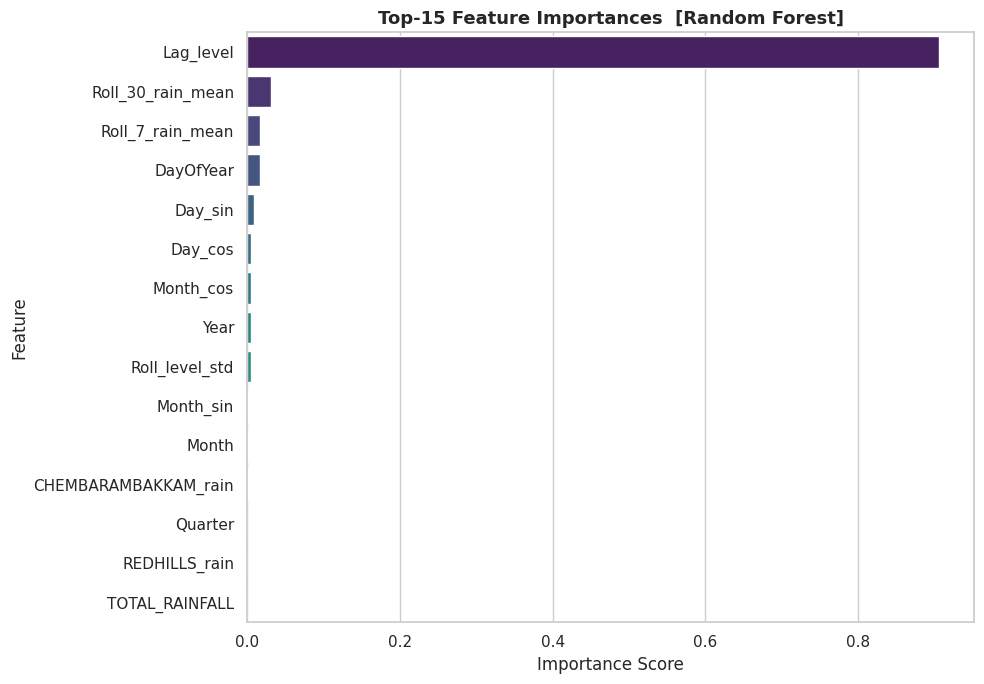

In [ ]:
# ── Extract feature importances (tree-based models only) ──────────────────────
tree_models = ["Random Forest", "Extra Trees", "Gradient Boosting", "XGBoost",
               "Decision Tree"]

available_tree = [m for m in tree_models if m in MODELS and
                  hasattr(MODELS[m], 'feature_importances_')]

if available_tree:
    fi_model_name = available_tree[0]     # pick best available tree model
    fi_model      = MODELS[fi_model_name]
    importances   = fi_model.feature_importances_

    fi_df = (pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
               .sort_values('Importance', ascending=False)
               .reset_index(drop=True))

    print(f"Feature Importances from: {fi_model_name}\n")
    display(fi_df.head(15))

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(15),
                palette='viridis', ax=ax)
    ax.set_title(f"Top-15 Feature Importances  [{fi_model_name}]",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based model available for feature importances in this run.")

---
## 🔄 BATCH 10 – Cross-Validation on Best Model

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
cv = TimeSeriesSplit(n_splits=5)

cv_r2   = cross_val_score(best_model, X_train_sc, y_train,
                          cv=cv, scoring='r2',
                          n_jobs=-1)
cv_rmse = cross_val_score(best_model, X_train_sc, y_train,
                          cv=cv,
                          scoring='neg_root_mean_squared_error',
                          n_jobs=-1)

print(f"Cross-Validation Results for  {best_name}")
print(f"{'─'*45}")
print(f"  R²    per fold : {np.round(cv_r2, 4)}")
print(f"  R²    mean     : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print(f"  RMSE  per fold : {np.round(-cv_rmse, 2)}")
print(f"  RMSE  mean     : {(-cv_rmse).mean():.2f}  ± {(-cv_rmse).std():.2f}")

Cross-Validation Results for  Lasso Regression
─────────────────────────────────────────────
  R²    per fold : [0.8056 0.8009 0.9277 0.6038 0.8993]
  R²    mean     : 0.8075  ± 0.1135
  RMSE  per fold : [897.32 907.31 597.94 544.52 960.29]
  RMSE  mean     : 781.48  ± 173.82


---
## 📅 BATCH 11 – Monthly & Seasonal Analysis

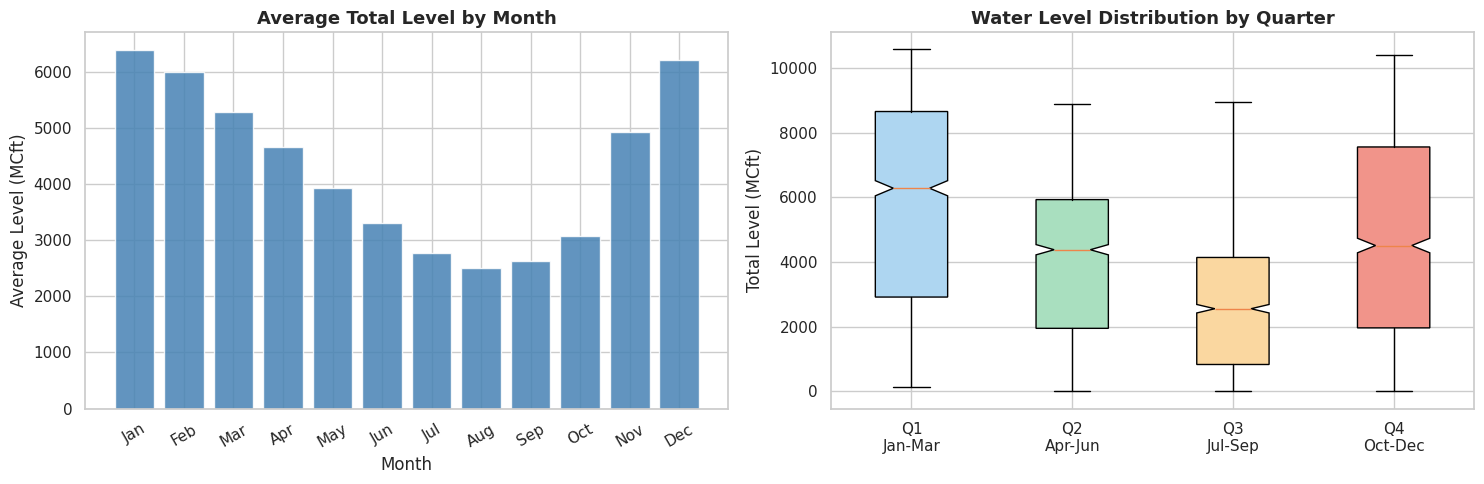

In [ ]:
# ── Monthly average total level ───────────────────────────────────────────────
monthly = df.groupby('Month')['TOTAL_LEVEL'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_Name'] = [month_names[m-1] for m in monthly['Month']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart – avg level by month
axes[0].bar(monthly['Month_Name'], monthly['TOTAL_LEVEL'],
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Average Total Level by Month", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average Level (MCft)")
axes[0].tick_params(axis='x', rotation=30)

# Box plot – level by quarter
bp_data = [df[df['Quarter'] == q]['TOTAL_LEVEL'].values for q in [1, 2, 3, 4]]
bp = axes[1].boxplot(bp_data, patch_artist=True, notch=True,
                     labels=['Q1\nJan-Mar', 'Q2\nApr-Jun',
                             'Q3\nJul-Sep', 'Q4\nOct-Dec'])
colors = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#F1948A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title("Water Level Distribution by Quarter", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Level (MCft)")

plt.tight_layout()
plt.show()

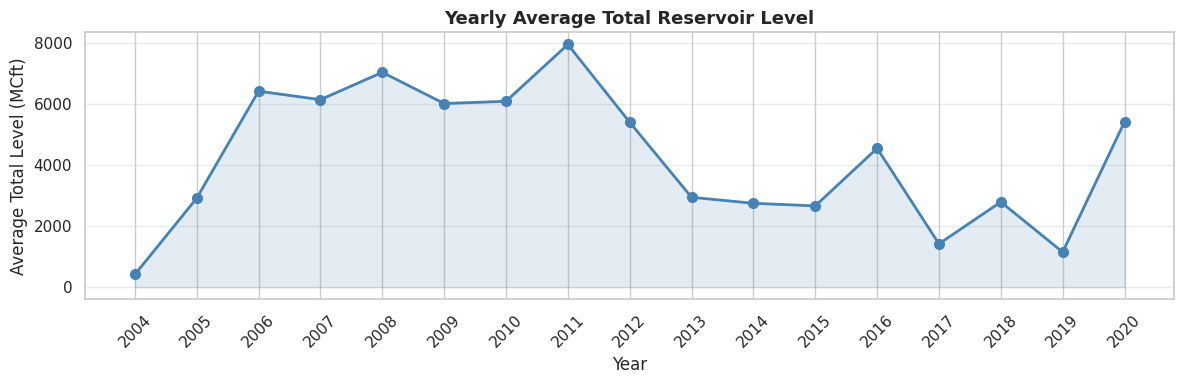

In [ ]:
# ── Yearly trend ─────────────────────────────────────────────────────────────
yearly = df.groupby('Year')['TOTAL_LEVEL'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly['Year'], yearly['TOTAL_LEVEL'],
        marker='o', linewidth=2, color='steelblue', markersize=7)
ax.fill_between(yearly['Year'], yearly['TOTAL_LEVEL'], alpha=0.15, color='steelblue')
ax.set_title("Yearly Average Total Reservoir Level", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Average Total Level (MCft)")
ax.grid(axis='y', alpha=0.4)
plt.xticks(yearly['Year'], rotation=45)
plt.tight_layout()
plt.show()

---
## 🔮 BATCH 12 – Predict with Custom Input

Use the function below to predict total reservoir level for **any given date and rainfall values**.

In [ ]:
def predict_reservoir_level(date_str,
                             poondi_rain=0, cholavaram_rain=0,
                             redhills_rain=0, chembarambakkam_rain=0,
                             last_lag_level=None,
                             roll_level_std=None):
    """
    Predict total reservoir water level.

    Parameters
    ----------
    date_str             : str   'YYYY-MM-DD'
    poondi_rain          : float daily rainfall at Poondi (mm)
    cholavaram_rain      : float daily rainfall at Cholavaram (mm)
    redhills_rain        : float daily rainfall at Red Hills (mm)
    chembarambakkam_rain : float daily rainfall at Chembarambakkam (mm)
    last_lag_level       : float total level from LAG days ago (default: dataset overall mean)
    roll_level_std       : float std deviation of level for past 7 days (default: dataset overall mean)

    Returns
    -------
    float : predicted total reservoir level (MCft)
    """
    d = pd.Timestamp(date_str)
    mean_level = df['TOTAL_LEVEL'].mean()

    # Use overall mean if specific lag level not provided
    lag_level_val = last_lag_level if last_lag_level is not None else mean_level

    total_rain = poondi_rain + cholavaram_rain + redhills_rain + chembarambakkam_rain

    rain_row    = [poondi_rain, cholavaram_rain, redhills_rain, chembarambakkam_rain]

    # Define default values for rolling features (using overall means from the dataset)
    # In a real-world scenario, these would ideally come from actual historical data
    roll_7_rain_mean_default  = df['Roll_7_rain_mean'].mean()
    roll_30_rain_mean_default = df['Roll_30_rain_mean'].mean()
    # Use the correct default for Roll_level_std
    roll_level_std_default_val  = roll_level_std if roll_level_std is not None else df['Roll_level_std'].mean()

    # Construct features in the exact order and count as FEATURE_COLS (17 features)
    features = (
        rain_row + # 4 features
        [d.year, d.month, d.quarter, d.dayofyear] + # 4 features
        [np.sin(2*np.pi*d.month/12), np.cos(2*np.pi*d.month/12)] + # 2 features
        [np.sin(2*np.pi*d.dayofyear/365), np.cos(2*np.pi*d.dayofyear/365)] + # 2 features
        [total_rain] + # 1 feature (TOTAL_RAINFALL)
        [lag_level_val] + # 1 feature (Lag_level)
        [roll_7_rain_mean_default] + # 1 feature (Roll_7_rain_mean)
        [roll_30_rain_mean_default] + # 1 feature (Roll_30_rain_mean)
        [roll_level_std_default_val] # 1 feature (Roll_level_std)
    )

    X_input    = np.array(features).reshape(1, -1)
    X_input_sc = scaler.transform(X_input)
    prediction = best_model.predict(X_input_sc)[0]
    return round(float(prediction), 2)

# ── Example prediction ─────────────────────────────────────────────────────────
example_date = '2021-09-15'
predicted    = predict_reservoir_level(
    date_str            = example_date,
    poondi_rain         = 45,
    cholavaram_rain     = 30,
    redhills_rain       = 60,
    chembarambakkam_rain= 20,
    last_lag_level      = 4800,
    roll_level_std      = 50
)
print(f"📅  Date            : {example_date}")
print(f"🌧️  Total Rainfall   : {45+30+60+20} mm across 4 reservoirs")
print(f"💧  Predicted Total Level : {predicted:,.2f} MCft  ({best_name})")

📅  Date            : 2021-09-15
🌧️  Total Rainfall   : 155 mm across 4 reservoirs
💧  Predicted Total Level : 4,613.76 MCft  (Lasso Regression)


---
## 💾 BATCH 13 – Save & Load the Best Model

In [ ]:
import joblib, os

SAVE_DIR = '/content/drive/MyDrive'    # change if needed
os.makedirs(SAVE_DIR, exist_ok=True)

model_path  = os.path.join(SAVE_DIR, 'best_model.pkl')
scaler_path = os.path.join(SAVE_DIR, 'scaler.pkl')

joblib.dump(best_model, model_path)
joblib.dump(scaler,     scaler_path)

print(f"✅ Model  saved → {model_path}")
print(f"✅ Scaler saved → {scaler_path}")

✅ Model  saved → /content/drive/MyDrive/best_model.pkl
✅ Scaler saved → /content/drive/MyDrive/scaler.pkl


In [ ]:
# ── Reload & quick sanity check ───────────────────────────────────────────────
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

test_pred_loaded = loaded_model.predict(loaded_scaler.transform(X_test))
r2_loaded        = r2_score(y_test, test_pred_loaded)
print(f"✅ Loaded model R² on test set: {r2_loaded:.4f}  (should match above)")

✅ Loaded model R² on test set: 0.9569  (should match above)


In [ ]:
import joblib
import os

SAVE_DIR = "/content"

model_path = os.path.join(SAVE_DIR, "best_model.pkl")
scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print("✅ Model saved:", model_path)
print("✅ Scaler saved:", scaler_path)

from google.colab import files
files.download(model_path)
files.download(scaler_path)

✅ Model saved: /content/best_model.pkl
✅ Scaler saved: /content/scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📝 BATCH 14 – Project Summary & Conclusion

In [ ]:
print("=" * 60)
print("      CHENNAI RESERVOIR LEVEL PREDICTION – SUMMARY")
print("=" * 60)
print(f"  Dataset period  : 2004-01-01  →  2020-12-03")
print(f"  Total records   : {len(df):,}")
print(f"  Features used   : {len(FEATURE_COLS)}")
print(f"  Models trained  : {len(MODELS)}")
print()
print("  Model Performance (Test Set):")
print(f"  {'─'*52}")
for _, row in results_df.iterrows():
    marker = '  🥇 ' if row['Model'] == best_name else '     '
    print(f"{marker}{row['Model']:<26}  R²={row['R2']:.4f}  RMSE={row['RMSE']:.1f}")
print()
print(f"  ✅ Best Model : {best_name}")
print(f"     R²         : {results_df.iloc[0]['R2']:.4f}")
print(f"     RMSE       : {results_df.iloc[0]['RMSE']:.2f} MCft")
print(f"     MAE        : {results_df.iloc[0]['MAE']:.2f} MCft")
print("=" * 60)

      CHENNAI RESERVOIR LEVEL PREDICTION – SUMMARY
  Dataset period  : 2004-01-01  →  2020-12-03
  Total records   : 6,109
  Features used   : 17
  Models trained  : 8

  Model Performance (Test Set):
  ────────────────────────────────────────────────────
  🥇 Lasso Regression            R²=0.9569  RMSE=458.8
     Linear Regression           R²=0.9568  RMSE=459.2
     Ridge Regression            R²=0.9568  RMSE=459.3
     Extra Trees                 R²=0.9411  RMSE=536.4
     Random Forest               R²=0.9389  RMSE=546.5
     Gradient Boosting           R²=0.9294  RMSE=587.4
     Decision Tree               R²=0.8666  RMSE=807.4
     XGBoost                     R²=0.8091  RMSE=965.9

  ✅ Best Model : Lasso Regression
     R²         : 0.9569
     RMSE       : 458.81 MCft
     MAE        : 354.39 MCft


In [ ]:
accuracy = r2_score(y_test, y_pred) * 100

print(f"Accuracy : {accuracy:.2f}%")

Accuracy : 95.69%


---

## 🎉 Project Complete!

| Step | Status |
|------|--------|
| Data loading & merging | ✅ |
| Exploratory Data Analysis | ✅ |
| Feature Engineering (lag, rolling, cyclical) | ✅ |
| Train / Test Split (chronological) | ✅ |
| 8 models trained & compared | ✅ |
| Best model identified & deep-dived | ✅ |
| Feature importance analysis | ✅ |
| 5-Fold cross-validation | ✅ |
| Monthly & seasonal analysis | ✅ |
| Prediction function for custom input | ✅ |
| Model saved to Google Drive | ✅ |

> **Next steps you can explore:**  
> - LSTM / GRU deep learning for sequence modeling  
> - Hyperparameter tuning with `GridSearchCV` or `Optuna`  
> - Deploy the saved model as a Flask / FastAPI web app  
> - Add weather forecast data for future-date predictions